In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# ---- change these before running ----
RAVDESS_DIR = "RAVDESS"
CREMAD_DIR = "CREMA-D"
EMOTIONS = ["happy", "sad"]     # pick any 2, must exist in both datasets
USE_FAKE_DATA = False           # set False once your paths above are correct

In [3]:
# ============================================================
# A1a - ENCODING
# turns one audio file into a list of numbers (features)
# ============================================================
def get_mfcc(file_path):
    signal, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    return np.mean(mfcc.T, axis=0)

In [4]:
# RAVDESS names look like 03-01-06-01-02-01-12.wav, 3rd number = emotion
def ravdess_label(filename):
    codes = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad",
             "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}
    return codes[filename.split("-")[2]]

In [5]:
# CREMA-D names look like 1001_DFA_ANG_XX.wav, 3rd part = emotion
def cremad_label(filename):
    codes = {"ANG": "angry", "DIS": "disgust", "FEA": "fearful",
             "HAP": "happy", "NEU": "neutral", "SAD": "sad"}
    return codes[filename.split("_")[2]]

In [6]:
def load_ravdess(folder, wanted_emotions):
    X, y = [], []
    for root, _, files in os.walk(folder):
        for f in files:
            if not f.endswith(".wav"):
                continue
            label = ravdess_label(f)
            if label in wanted_emotions:
                X.append(get_mfcc(os.path.join(root, f)))
                y.append(label)
    return X, y

In [7]:
def load_cremad(folder, wanted_emotions):
    X, y = [], []
    for root, _, files in os.walk(folder):
        for f in files:
            if not f.endswith(".wav"):
                continue
            label = cremad_label(f)
            if label in wanted_emotions:
                X.append(get_mfcc(os.path.join(root, f)))
                y.append(label)
    return X, y

In [8]:
# just for testing the code before real data is ready (not part of A1-A9)
def fake_dataset(n=200, features=13):
    rng = np.random.default_rng(0)
    class1 = rng.normal(0, 1, (n // 2, features))
    class2 = rng.normal(3, 1, (n // 2, features))
    X = np.vstack([class1, class2])
    y = ["happy"] * (n // 2) + ["sad"] * (n // 2)
    return X, y

In [9]:
# A1a continued - turns "happy"/"sad" text labels into 0/1 numbers
def encode_labels(y):
    classes = sorted(set(y))
    mapping = {c: i for i, c in enumerate(classes)}
    return np.array([mapping[val] for val in y]), mapping

In [10]:
# ============================================================
# A1b - DATA IMPUTATION
# fills missing values using mean, median, or mode
# ============================================================
def fill_missing(X, method="mean"):
    X = np.array(X, dtype=float)
    out = X.copy()
    for col in range(X.shape[1]):
        values = X[:, col]
        missing = np.isnan(values)
        if not missing.any():
            continue
        if method == "mean":
            fill = np.nanmean(values)
        elif method == "median":
            fill = np.nanmedian(values)
        else:
            fill = Counter(values[~missing]).most_common(1)[0][0]
        out[missing, col] = fill
    return out

In [11]:
# ============================================================
# A1c - DISTANCE CALCULATION
# three different distance metrics, pick any at prediction time
# ============================================================
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [12]:
def manhattan(a, b):
    return np.sum(np.abs(a - b))

In [13]:
def minkowski(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

In [14]:
# distance from one test point to every training point
def all_distances(X_train, point, metric="euclidean"):
    dists = np.zeros(len(X_train))
    for i, row in enumerate(X_train):
        if metric == "euclidean":
            dists[i] = euclidean(row, point)
        elif metric == "manhattan":
            dists[i] = manhattan(row, point)
        else:
            dists[i] = minkowski(row, point)
    return dists

In [15]:
# ============================================================
# A1d - SORTING
# 3 DSA sorting algorithms, chosen via the algo="..." parameter
# ============================================================
def bubble_sort(pairs):
    arr = pairs[:]
    for i in range(len(arr)):
        for j in range(len(arr) - i - 1):
            if arr[j][0] > arr[j + 1][0]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

In [16]:
def insertion_sort(pairs):
    arr = pairs[:]
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j][0] > key[0]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

In [17]:
def merge_sort(pairs):
    if len(pairs) <= 1:
        return pairs
    mid = len(pairs) // 2
    left = merge_sort(pairs[:mid])
    right = merge_sort(pairs[mid:])
    result, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        if left[i][0] <= right[j][0]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    return result + left[i:] + right[j:]

In [18]:
# config parameter picks which sorting algorithm runs
def sort_distances(dists, algo="merge"):
    pairs = list(zip(dists, range(len(dists))))
    if algo == "bubble":
        return bubble_sort(pairs)
    elif algo == "insertion":
        return insertion_sort(pairs)
    else:
        return merge_sort(pairs)

In [19]:
# ============================================================
# A1e - IDENTIFY NEIGHBORS
# grabs the k closest points, breaks ties by earliest index
# ============================================================
def get_neighbors(sorted_pairs, k):
    cutoff = sorted_pairs[k - 1][0]
    sure = [p for p in sorted_pairs if p[0] < cutoff]
    tied = sorted([p for p in sorted_pairs if p[0] == cutoff], key=lambda p: p[1])
    return sure + tied[:k - len(sure)]

In [20]:
# ============================================================
# A1f - CLASS EVALUATION AND ASSIGNMENT (majority voting + tie-break)
# A2  - WEIGHTED kNN (weighted_vote uses 1/distance as vote strength)
# ============================================================
def majority_vote(neighbors, y_train):
    counts = defaultdict(int)
    for dist, idx in neighbors:
        counts[y_train[idx]] += 1
    top = max(counts.values())
    winners = [c for c, v in counts.items() if v == top]
    if len(winners) == 1:
        return winners[0]
    # tie-break: class of the single closest neighbor among tied classes
    for dist, idx in sorted(neighbors):
        if y_train[idx] in winners:
            return y_train[idx]

In [21]:
def weighted_vote(neighbors, y_train):
    weights = defaultdict(float)
    for dist, idx in neighbors:
        weights[y_train[idx]] += 1 / (dist + 1e-6)   # closer neighbor = more weight
    top = max(weights.values())
    winners = [c for c, v in weights.items() if v == top]
    if len(winners) == 1:
        return winners[0]
    for dist, idx in sorted(neighbors):
        if y_train[idx] in winners:
            return y_train[idx]

In [22]:
# ============================================================
# A7 - FIT / PREDICT / SCORE FUNCTIONS
# (kNN is "lazy" - fit just stores the data, no real training happens)
# ============================================================
def fit(X_train, y_train):
    return {"X": np.array(X_train, dtype=float), "y": np.array(y_train)}

In [23]:
def predict(model, X_test, k, metric="euclidean", algo="merge", weighted=False):
    preds = []
    for point in np.array(X_test, dtype=float):
        dists = all_distances(model["X"], point, metric)
        sorted_pairs = sort_distances(dists, algo)
        neighbors = get_neighbors(sorted_pairs, k)
        vote = weighted_vote if weighted else majority_vote
        preds.append(vote(neighbors, model["y"]))
    return np.array(preds)

In [24]:
def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

loaded 3231 audio clips
labels: {'happy': 0, 'sad': 1}


my knn accuracy: 0.8144329896907216
sklearn knn accuracy: 0.8144329896907216


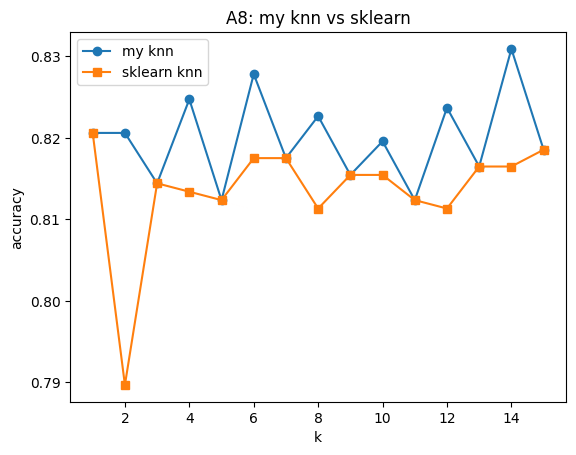

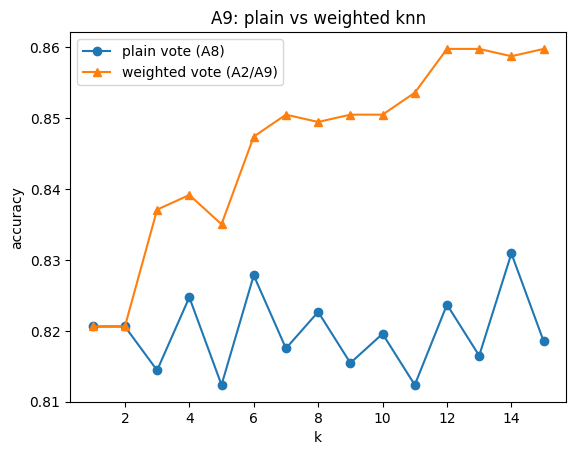

In [25]:
# ---------------- main ----------------
if __name__ == "__main__":

    # ============================================================
    # LOAD DATA (feeds into A1a encoding + A3 train/test split below)
    # ============================================================
    if USE_FAKE_DATA:
        raw_X, raw_y = fake_dataset()
        print("using fake data for now, flip USE_FAKE_DATA to False for real audio")
    else:
        rav_X, rav_y = load_ravdess(RAVDESS_DIR, EMOTIONS)
        crema_X, crema_y = load_cremad(CREMAD_DIR, EMOTIONS)
        raw_X = rav_X + crema_X
        raw_y = rav_y + crema_y
        print(f"loaded {len(raw_X)} audio clips")

    # A1a - encode text labels to numbers
    y_encoded, label_map = encode_labels(raw_y)
    print("labels:", label_map)

    # A1b - impute any missing feature values
    X_clean = fill_missing(np.array(raw_X))

    # ============================================================
    # A3 - TRAIN/TEST SPLIT (uses sklearn's train_test_split, as required)
    # ============================================================
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_encoded, test_size=0.3, random_state=42)

    # ============================================================
    # A4, A5, A6 - Train (fit), test accuracy (score), predict
    # ============================================================
    model = fit(X_train, y_train)
    my_preds = predict(model, X_test, k=3)             # A6 - predict()
    print("my knn accuracy:", accuracy(y_test, my_preds))   # A5 - score

    # sklearn's built-in version, for comparison (also A4-A6 using their package)
    sk_model = KNeighborsClassifier(n_neighbors=3)
    sk_model.fit(X_train, y_train)
    print("sklearn knn accuracy:", sk_model.score(X_test, y_test))

    # ============================================================
    # A8 - Compare my kNN vs sklearn kNN across a range of k, plot both
    # ============================================================
    k_range = range(1, 16)
    my_acc, sk_acc, weighted_acc = [], [], []

    for k in k_range:
        my_acc.append(accuracy(y_test, predict(model, X_test, k)))
        weighted_acc.append(accuracy(y_test, predict(model, X_test, k, weighted=True)))  # A9 data
        temp_sk = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
        sk_acc.append(temp_sk.score(X_test, y_test))

    plt.figure(1)
    plt.plot(k_range, my_acc, marker="o", label="my knn")
    plt.plot(k_range, sk_acc, marker="s", label="sklearn knn")
    plt.xlabel("k")
    plt.ylabel("accuracy")
    plt.legend()
    plt.title("A8: my knn vs sklearn")
    plt.savefig("compare_sklearn.png")

    # ============================================================
    # A9 - Weighted kNN vs plain kNN comparison, plotted
    # ============================================================
    plt.figure(2)
    plt.plot(k_range, my_acc, marker="o", label="plain vote (A8)")
    plt.plot(k_range, weighted_acc, marker="^", label="weighted vote (A2/A9)")
    plt.xlabel("k")
    plt.ylabel("accuracy")
    plt.legend()
    plt.title("A9: plain vs weighted knn")
    plt.savefig("compare_weighted.png")

    # show both figures together (only one show() call for both windows)
    plt.show()